In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

## **Modelo de Parcial Integrador** 

## **Fundamentos de Ciencia de Datos** 

## � **Descripción del dataset** 

El dataset `nacimientos.csv` contiene la siguiente información registrada en un efector de salud sobre un total de 345 madres que dieron a luz en el último año: peso del recién nacido (kg), semanas de gestación, número de partos previos atravesados y edad de la madre al momento del nacimiento. Por otro lado, se registró el peso (kg) y la altura (m) de las mujeres luego del parto y se las indagó acerca del número de cigarrillos que suelen consumir a diario, información que se encuentra en el dataset `datos_madres.xlsx.` 

## **PARTE I** 

**Ejercicio 1.** Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis. 

In [15]:
nacimientos=pd.read_csv('nacimientos.csv',sep=';',skiprows=3)
nacimientos

,id_madre,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos
0,1,3057.4,38.8,21,1
1,2,2716.6,38.1,26,0
2,3,3230.8,39.1,18,1
3,4,3473.3,41.8,28,2
4,5,2951.5,38.0,29,3
...,...,...,...,...,...
340,341,2332.4,34.0,25,2
341,342,2781.0,36.7,25,2
342,343,2767.0,37.4,19,2
343,344,3034.0,38.9,39,5


In [19]:
nacimientos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_madre       345 non-null    int64  
 1   peso_kg_bebe   345 non-null    float64
 2   semanas_gest   345 non-null    float64
 3   edad_anios     345 non-null    int64  
 4   hijos_previos  345 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 13.6 KB


In [16]:
madres=pd.read_excel('datos_madres.xlsx')
madres.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   345 non-null    int64  
 1   ALTURA_M_MUJER       345 non-null    object 
 2   PESO_KG_MUJER        345 non-null    float64
 3   NUM_CIGARRILLOS_DIA  345 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 10.9+ KB


In [17]:
madres['ALTURA_M_MUJER']=madres['ALTURA_M_MUJER'].str.replace(',','.').astype('float')

In [18]:
madres.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   345 non-null    int64  
 1   ALTURA_M_MUJER       345 non-null    float64
 2   PESO_KG_MUJER        345 non-null    float64
 3   NUM_CIGARRILLOS_DIA  345 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 10.9 KB


**Ejercicio 2.** Considerando que el Índice de Masa Corporal (IMC) se define como **el peso de una persona en kilogramos dividido por el cuadrado de la estatura en metros** , represente gráficamente la distribución de dicha variable para las mujeres del dataset. En base al gráfico realizado, ¿cómo caracterizaría su distribución en relación a la simetría? 

In [21]:
madres['imc']=madres['PESO_KG_MUJER']/(madres['ALTURA_M_MUJER']**2)
madres['imc']

0      17.734375
1      23.906250
2      20.390625
3      26.604938
4      19.619377
         ...    
340    22.595156
341    20.415225
342    17.577855
343    26.222222
344    20.415225
Name: imc, Length: 345, dtype: float64

In [28]:
madres['imc'].skew()
print(f'El coeficiente de asimetria es {round(madres['imc'].skew(),2)}, como es positivo hay una cola mas larga hacia la derecha(ASIMETRIA A LA DERECHA)')

El coeficiente de asimetria es 1.38, como es positivo hay una cola mas larga hacia la derecha(ASIMETRIA A LA DERECHA)


Text(0, 0.5, 'Cantidad de mujeres')

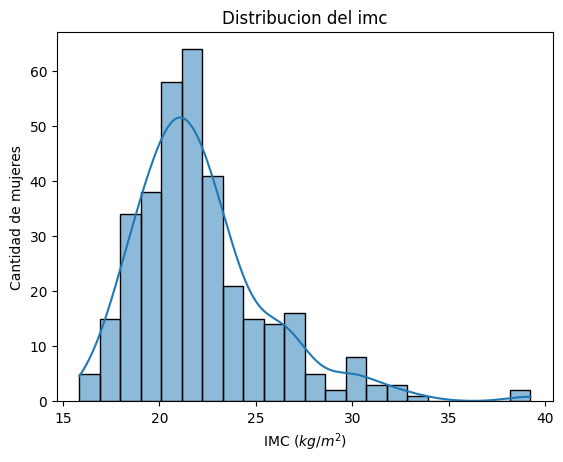

In [27]:
sns.histplot(madres['imc'],kde=True)
plt.title('Distribucion del imc')
plt.xlabel('IMC ($kg/m^2$)')
plt.ylabel('Cantidad de mujeres')

**Ejercicio 3.** Genere una variable categórica binaria realizando la _dicotomización_ de la variable vinculada con el número de cigarrillos consumidos a diario, diferenciando aquellas mujeres que no fuman habitualmente (no consumen cigarrillos) de aquellas que sí lo hacen (consumen 1 o más cigarrillos diariamente). ¿Qué porcentaje de las mujeres del dataset son fumadoras? 

In [30]:
madres['fumadora']=madres['NUM_CIGARRILLOS_DIA'].apply(lambda x:0 if x == 0 else 1)
madres['fumadora']

0      0
1      1
2      1
3      0
4      1
      ..
340    1
341    1
342    1
343    1
344    0
Name: fumadora, Length: 345, dtype: int64

In [37]:
porcentaje_fumadoras=len(madres[madres['fumadora']==1])*100/len(madres)
print(f'El porcentaje de fumadoras es {porcentaje_fumadoras:.2f}%')

El porcentaje de fumadoras es 55.94%


**Ejercicio 4.** Represente gráficamente la distribución del peso de los recién nacidos en función del carácter o no de fumadora de la madre (variable generada en el ítem anterior). Comente brevemente lo observado. 


In [39]:
df_completo=pd.merge(left=madres, right=nacimientos, left_on='ID', right_on='id_madre',how='inner')
df_completo

,ID,ALTURA_M_MUJER,PESO_KG_MUJER,NUM_CIGARRILLOS_DIA,imc,fumadora,id_madre,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos
0,1,1.6,45.4,0,17.734375,0,1,3057.4,38.8,21,1
1,2,1.6,61.2,9,23.906250,1,2,2716.6,38.1,26,0
2,3,1.6,52.2,2,20.390625,1,3,3230.8,39.1,18,1
3,4,1.8,86.2,0,26.604938,0,4,3473.3,41.8,28,2
4,5,1.7,56.7,4,19.619377,1,5,2951.5,38.0,29,3
...,...,...,...,...,...,...,...,...,...,...,...
340,341,1.7,65.3,2,22.595156,1,341,2332.4,34.0,25,2
341,342,1.7,59.0,2,20.415225,1,342,2781.0,36.7,25,2
342,343,1.7,50.8,9,17.577855,1,343,2767.0,37.4,19,2
343,344,1.5,59.0,6,26.222222,1,344,3034.0,38.9,39,5


C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_5988\2609618860.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo,x='fumadora',y='peso_kg_bebe',palette='Set1')


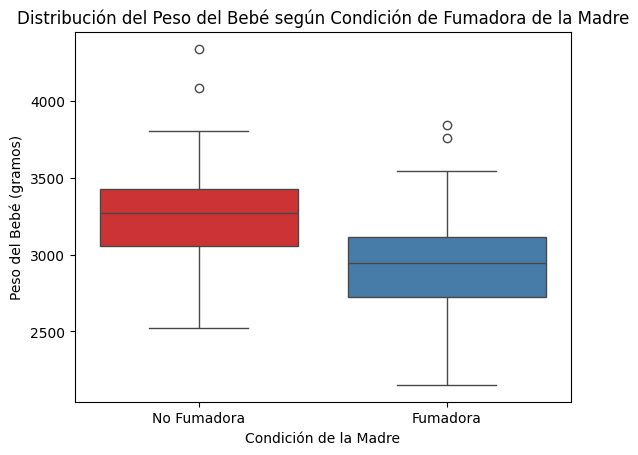

In [44]:
sns.boxplot(data=df_completo,x='fumadora',y='peso_kg_bebe',palette='Set1')
plt.xticks([0, 1], ['No Fumadora', 'Fumadora'])
plt.title('Distribución del Peso del Bebé según Condición de Fumadora de la Madre')
plt.xlabel('Condición de la Madre')
plt.ylabel('Peso del Bebé (gramos)')
plt.show()

* Los bebes hijos de madres no fumadoras tienen un mayor peso que los de fumadoras, denota un impacto negativo del tabaquismo durante el embarazo


**Ejercicio 5.** Realice un gráfico que le permita caracterizar el grado de asociación lineal que existe entre las diferentes variables cuantitativas estudiadas. ¿Cuáles son los pares de variables que presentan una asociación lineal más intensa? Justifique. 

Text(0.5, 1.0, 'Matriz de Correlación Lineal entre Variables Cuantitativas')

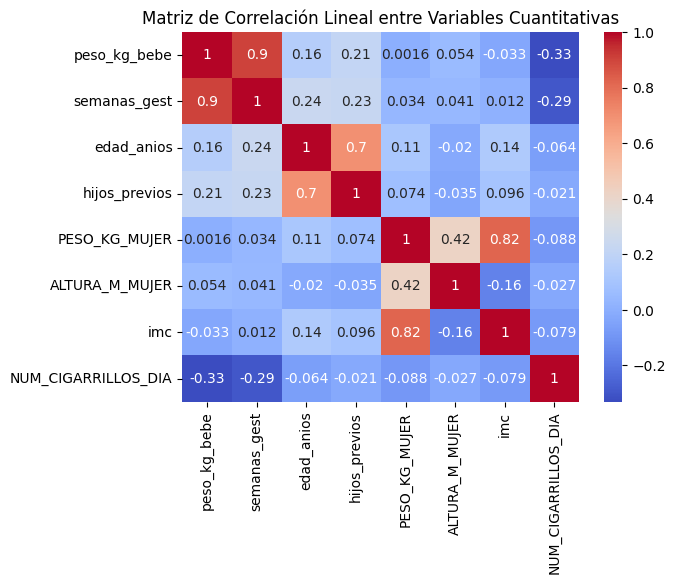

In [49]:
columnas_cuantitativas = ['peso_kg_bebe', 'semanas_gest', 'edad_anios', 'hijos_previos', 'PESO_KG_MUJER', 'ALTURA_M_MUJER', 'imc', 'NUM_CIGARRILLOS_DIA']
sns.heatmap(df_completo[columnas_cuantitativas].corr(), annot=True,cmap='coolwarm')
plt.title('Matriz de Correlación Lineal entre Variables Cuantitativas')

* Hay una relacion directa y positiva entre el peso del bebe y las semanas de gestacion. $r=0.9$ 
* tambien hay una relacion fuerte entre el IMC de la madre y el peso de la madre. Es logico y esperable por definicion
* La ultima relacion moderada-fuerte que hay es de 0.7 entre hijos previos y edad de la madre 

-----------------------------

## **PARTE II** 

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal múltiple que permita predecir el peso de los recién nacidos en función de las semanas de gestación, el número de partos previos atravesados por la madre, la edad de la madre, su índice de masa corporal (IMC) y el carácter o no de fumadora. 

- a. Ajuste el modelo completo, incluyendo la totalidad de las variables predictoras de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar las diferencias en el peso promedio de los recién nacidos con un nivel de significación del 1%? Justifique. 

- b. Si a partir de su respuesta en el ítem anterior considera la posibilidad de ajustar un nuevo modelo que incluya menos variables predictoras que el modelo completo, realice el ajuste. De lo contrario, pase al ítem siguiente. 

In [52]:
modelo=smf.ols('peso_kg_bebe ~ semanas_gest + imc + fumadora + edad_anios + hijos_previos',data=df_completo).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           peso_kg_bebe   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     356.2
Date:               do., 07 jun. 2026   Prob (F-statistic):          1.50e-132
Time:                        00:17:35   Log-Likelihood:                -2177.1
No. Observations:                 345   AIC:                             4366.
Df Residuals:                     339   BIC:                             4389.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -1531.1921    156.252     -9.799

* todas las variables tienen un p-value<0.05, la mas cercana es la del imc que es 0.042 pero la considero significativa

- c. Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el valor del coeficiente estimado por el modelo para la variable **semanas de gestación.** 

$\hat{y}=-1531.1921+125.5327*x_{semanas}-4.2835*x_{IMC}-93.1241*x_{fuma}-6.5742*x_{edad}+17.2778*x_{hijos}$

por cada semana de gestacion se incrementa en 125.5327 gramos el peso del bebe

- d. Una médica quiere estimar el peso al nacer que tendrá un bebé que dará a luz una madre primeriza no fumadora de 25 años, que posee un índice de masa corporal de 19.5 kg/m[2] , luego de un total de 38 semanas de gestación. Utilice el último modelo ajustado para informarle un peso estimado. 

In [53]:
prediccion=-1531.1921+125.5327*38-4.2835*19.5-93.1241*0-6.5742*25+17.2778*0
print(f'La prediccion segun el modelo es de {prediccion:.2f} gramos')

La prediccion segun el modelo es de 2991.17 gramos


- e. Represente gráficamente la distribución de los residuos del modelo y comente brevemente las características que observa. 

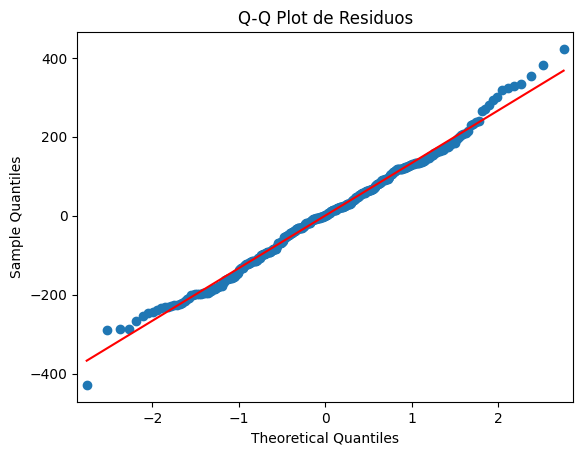

In [54]:
# Normalidad de Residuos
sm.qqplot(modelo.resid, line='s')
plt.title("Q-Q Plot de Residuos")
plt.show()

* Los puntos se encuentran alineados sobre la diagonal, entonces cumplen con el supuesto de normalidad. 

-----------------------------

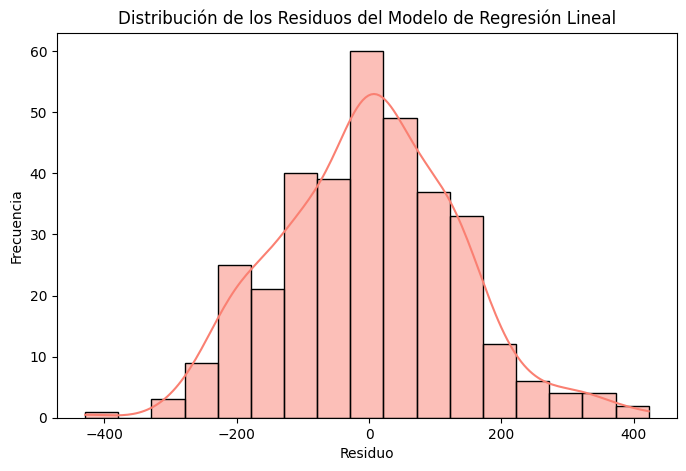

In [56]:
# Obtención de los residuos
df_completo['residuos'] = modelo.resid

# Graficar histograma de residuos
plt.subplots(figsize=(8, 5))
sns.histplot(df_completo['residuos'], kde=True, color='salmon')
plt.title('Distribución de los Residuos del Modelo de Regresión Lineal')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.show()